In [160]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
import nltk

import warnings
warnings.filterwarnings('ignore')


In [161]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [162]:
df = pd.read_csv(r'SMS_spam.csv', encoding='Windows-1252')
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
2091,ham,Then get some cash together and I'll text jason,NaN,NaN,NaN
504,spam,+123 Congratulations - in this week's competit...,NaN,NaN,NaN
4751,ham,Well boy am I glad G wasted all night at apple...,NaN,NaN,NaN
4414,ham,"Yeah I should be able to, I'll text you when I...",NaN,NaN,NaN
1941,spam,WELL DONE! Your 4* Costa Del Sol Holiday or å£...,NaN,NaN,NaN


In [163]:
df.shape

(5572, 5)

## Data cleaning

In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [165]:
#checking missing values
df.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [166]:
#check for duplicate values
df.duplicated().sum()

403

In [167]:
#remove duplicates
df=df.drop_duplicates(keep='first')

In [168]:
df.duplicated().sum()

0

In [169]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [170]:
df.columns=['target','text']
df.head(1)

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."


In [171]:
df['target'].replace({'ham':0,'spam':1},inplace=True)

In [172]:
df.sample(5)

,target,text
2095,0,"Probably, want to pick up more?"
2336,0,\Aww you must be nearly dead!Well Jez isComing...
2221,0,I notice you like looking in the shit mirror y...
2520,0,Misplaced your number and was sending texts to...
5554,0,Well keep in mind I've only got enough gas for...


## EDA

In [173]:
df['target'].value_counts()

,count
target,
0,4516
1,653


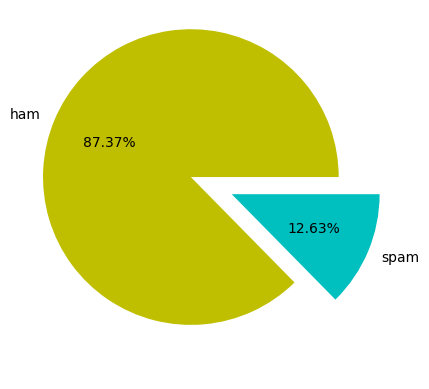

In [174]:
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct='%0.2f%%',colors='yc',explode=[0.3,0])
plt.show()

In [175]:
#Data is imbalance

In [176]:
#no of characters in each text
df['num_of-char']=df['text'].apply(len)
df.head(2)

,target,text,num_of-char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29


In [177]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [178]:
#no of words in each text
df['num_of_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [179]:
df.head(2)

,target,text,num_of-char,num_of_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8


In [180]:
#no of sentences in each text
df['num_of_sentences']=df['text'].apply(lambda x :len(nltk.sent_tokenize(x)))

In [181]:
df.head()

,target,text,num_of-char,num_of_words,num_of_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [182]:
df[['num_of-char','num_of_words','num_of_sentences']].describe()

,num_of-char,num_of_words,num_of_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [183]:
#ham
df[df['target']==0][['num_of-char','num_of_words','num_of_sentences']].describe()

,num_of-char,num_of_words,num_of_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [184]:
#spam
df[df['target']==1][['num_of-char','num_of_words','num_of_sentences']].describe()

,num_of-char,num_of_words,num_of_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_of-char', ylabel='Density'>

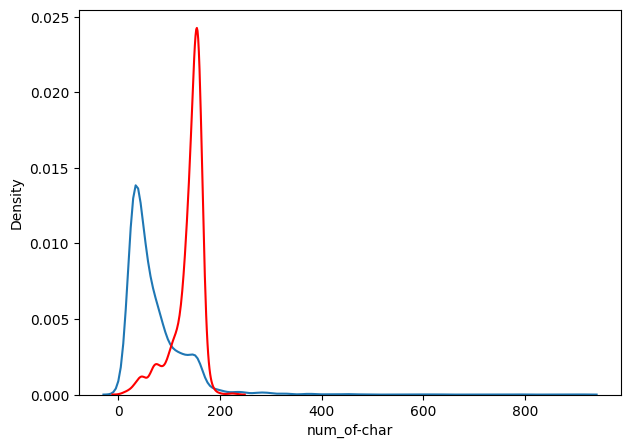

In [185]:
#ham
plt.figure(figsize=(7,5))
sns.kdeplot(df[df['target']==0]['num_of-char'])
sns.kdeplot(df[df['target']==1]['num_of-char'],color='red')

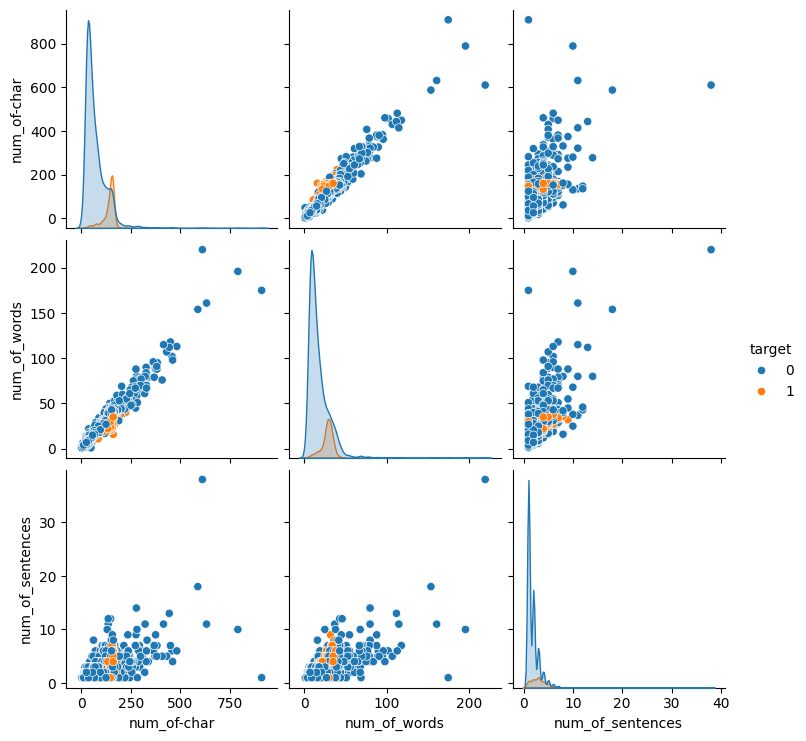

In [186]:
sns.pairplot(df,hue='target')

<Axes: >

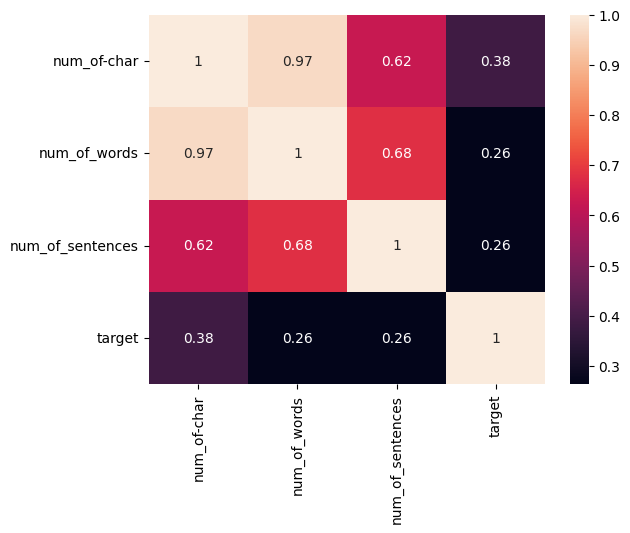

In [187]:
sns.heatmap(df[['num_of-char','num_of_words','num_of_sentences','target']].corr(),annot=True)

## Text pre-processing

In [188]:
# *lower case
# *Tokenization
# *Removing special characters
# *removing stop words and punctuation
# *stemming/lemmitazation



In [189]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()
ps.stem('loving')

'love'

In [190]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['i',
 'me',
 'my',
 'myself',
 'we',
 'our',
 'ours',
 'ourselves',
 'you',
 "you're",
 "you've",
 "you'll",
 "you'd",
 'your',
 'yours',
 'yourself',
 'yourselves',
 'he',
 'him',
 'his',
 'himself',
 'she',
 "she's",
 'her',
 'hers',
 'herself',
 'it',
 "it's",
 'its',
 'itself',
 'they',
 'them',
 'their',
 'theirs',
 'themselves',
 'what',
 'which',
 'who',
 'whom',
 'this',
 'that',
 "that'll",
 'these',
 'those',
 'am',
 'is',
 'are',
 'was',
 'were',
 'be',
 'been',
 'being',
 'have',
 'has',
 'had',
 'having',
 'do',
 'does',
 'did',
 'doing',
 'a',
 'an',
 'the',
 'and',
 'but',
 'if',
 'or',
 'because',
 'as',
 'until',
 'while',
 'of',
 'at',
 'by',
 'for',
 'with',
 'about',
 'against',
 'between',
 'into',
 'through',
 'during',
 'before',
 'after',
 'above',
 'below',
 'to',
 'from',
 'up',
 'down',
 'in',
 'out',
 'on',
 'off',
 'over',
 'under',
 'again',
 'further',
 'then',
 'once',
 'here',
 'there',
 'when',
 'where',
 'why',
 'how',
 'all',
 'any',
 'both',
 'each

In [191]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [192]:
def transform_text(text):
    text=text.lower()
    text=nltk.word_tokenize(text) #to seprate words

    y=[]
    for i in text:   #to remove special char
        if i.isalnum():
            y.append(i)

    text=y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)


    text=y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))



    return ' '.join(y)

In [193]:
transform_text('did you liking my presenting on ml?')

'like present ml'

In [194]:
df['transformed_text']=df['text'].apply(transform_text)

In [195]:
df.head(2)

,target,text,num_of-char,num_of_words,num_of_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni


In [196]:
from wordcloud import WordCloud
wc=WordCloud(width=500,height=500,background_color='white',min_font_size=10)

In [197]:
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))

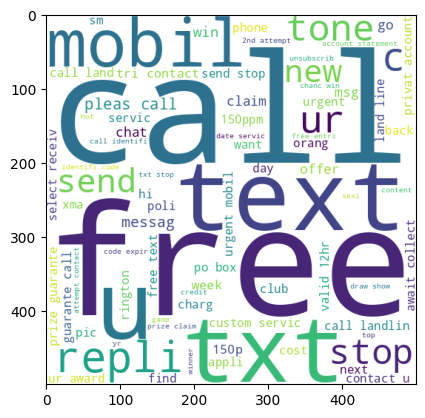

In [198]:
plt.imshow(spam_wc)

In [199]:
#do above same process to create word cloud for ham emails

In [200]:
#fetching top 30 words from ham and spam mails
spam_corpus=[]
list1=df[df['target']==1]['transformed_text'].to_list()
for msg in list1:
    for word in msg.split():
        spam_corpus.append(word)


In [201]:
len(spam_corpus)

9939

In [202]:
from collections import Counter
Counter(spam_corpus).most_common(30)

[('call', 320),
 ('free', 191),
 ('2', 155),
 ('txt', 141),
 ('text', 122),
 ('u', 119),
 ('ur', 119),
 ('mobil', 114),
 ('stop', 104),
 ('repli', 103),
 ('claim', 98),
 ('4', 97),
 ('prize', 82),
 ('get', 74),
 ('new', 64),
 ('servic', 64),
 ('tone', 63),
 ('send', 60),
 ('urgent', 57),
 ('nokia', 57),
 ('contact', 56),
 ('award', 55),
 ('phone', 52),
 ('cash', 51),
 ('pleas', 51),
 ('week', 49),
 ('win', 48),
 ('c', 45),
 ('collect', 45),
 ('min', 45)]

In [203]:
com30=pd.DataFrame(Counter(spam_corpus).most_common(30))[0]
com30count=pd.DataFrame(Counter(spam_corpus).most_common(30))[1]

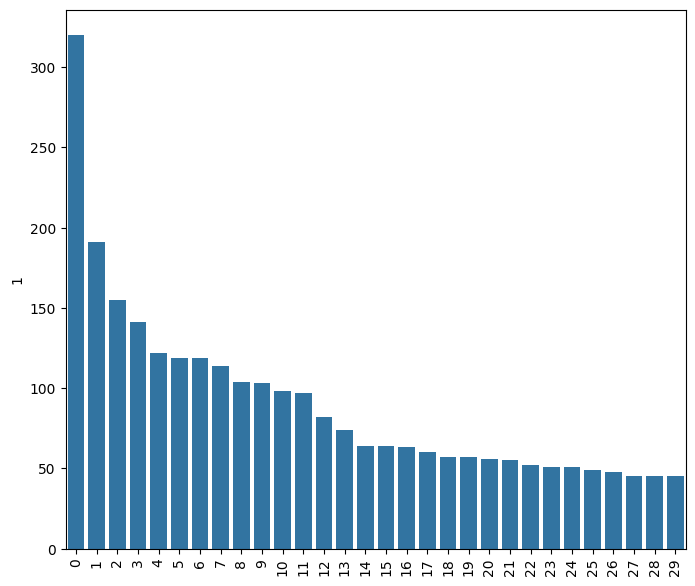

In [204]:
plt.figure(figsize=(8,7))
sns.barplot(com30count)
# plt.xlabel(com30)
plt.xticks(rotation='vertical')
plt.show()

In [205]:
ham_corpus=[]
list2=df[df['target']==0]['transformed_text'].to_list()
for msg in list2:
    for word in msg.split():
        ham_corpus.append(word)


In [206]:
len(ham_corpus)

35404

In [207]:
from collections import Counter
Counter(ham_corpus).most_common(30)

[('u', 883),
 ('go', 404),
 ('get', 349),
 ('gt', 288),
 ('lt', 287),
 ('2', 284),
 ('come', 275),
 ('got', 236),
 ('know', 236),
 ('like', 234),
 ('call', 233),
 ('time', 219),
 ('ok', 217),
 ('love', 216),
 ('good', 213),
 ('want', 208),
 ('ur', 197),
 ('day', 190),
 ('need', 170),
 ('one', 165),
 ('lor', 159),
 ('4', 156),
 ('home', 152),
 ('think', 149),
 ('see', 147),
 ('take', 143),
 ('still', 143),
 ('da', 142),
 ('tell', 133),
 ('make', 129)]

In [208]:
com30=pd.DataFrame(Counter(ham_corpus).most_common(30))[0]
com30count=pd.DataFrame(Counter(ham_corpus).most_common(30))[1]

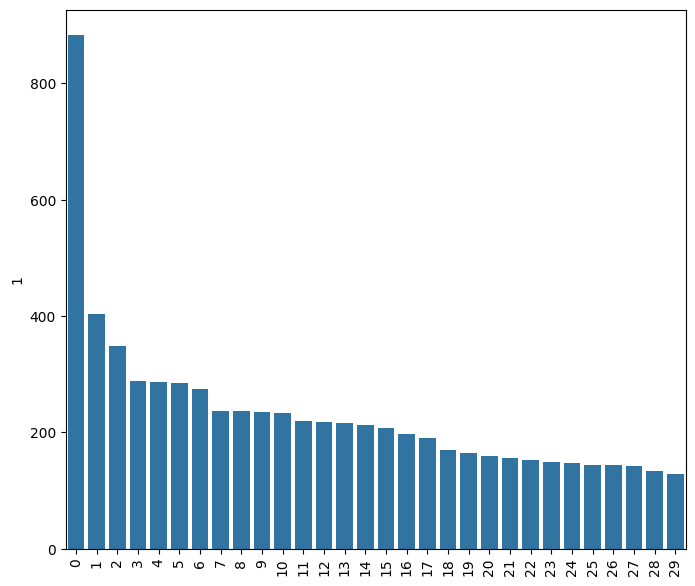

In [209]:
plt.figure(figsize=(8,7))
sns.barplot(com30count)
plt.xticks(rotation='vertical')
plt.show()

## Model building

In [210]:
df.sample(2)

,target,text,num_of-char,num_of_words,num_of_sentences,transformed_text
2849,0,She's fine. Good to hear from you. How are you...,74,21,4,fine good hear dear happi new year oh
4317,0,S...i will take mokka players only:),36,10,1,take mokka player


In [238]:
#to build model we need numerical data
#text is not numarical so will convert text into vectors
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer

In [270]:
cv=CountVectorizer()
tfidf=TfidfVectorizer(max_features=3000)

In [271]:
X=tfidf.fit_transform(df['transformed_text']).toarray() #toaaru used to convert sparse array into dense array

In [ ]:
#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#X = scaler.fit_transform(X)

In [ ]:
# appending the num_character col to X
#X = np.hstack((X,df['num_characters'].values.reshape(-1,1)))

In [272]:
X.shape

(5169, 3000)

In [273]:
Y=df['target'].values

In [274]:
Y.shape

(5169,)

In [275]:
Y

array([0, 0, 1, ..., 0, 0, 0])

In [276]:
from sklearn.model_selection import train_test_split

In [277]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [278]:

x_train.shape,y_train.shape,x_test.shape,y_test.shape


((4135, 3000), (4135,), (1034, 3000), (1034,))

In [279]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB

In [280]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [281]:
gnb.fit(x_train,y_train)
y_pred1=gnb.predict(x_test)

In [282]:
mnb.fit(x_train,y_train)
y_pred2=mnb.predict(x_test)

In [283]:
bnb.fit(x_train,y_train)
y_pred3=bnb.predict(x_test)

## Evluation

In [284]:
#sms or email classification is high precison model we try to reduce TP rate
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [285]:
print('accuracy score for gnb:',accuracy_score(y_test,y_pred1))
print('precision score for gnb:',precision_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))


accuracy score for gnb: 0.8694390715667312
precision score for gnb: 0.5068493150684932
[[788 108]
 [ 27 111]]


In [286]:
print('accuracy score for bnb:',accuracy_score(y_test,y_pred3))
print('precision score for bnb:',precision_score(y_test,y_pred3))


accuracy score for bnb: 0.9835589941972921
precision score for bnb: 0.991869918699187


In [287]:
print('accuracy score for mnb:',accuracy_score(y_test,y_pred2))
print('precision score for mnb:',precision_score(y_test,y_pred2))

accuracy score for mnb: 0.9709864603481625
precision score for mnb: 1.0


In [288]:
# precision is important as its not giving any false positive so will go with MultinomialNB

In [289]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [295]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [296]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [297]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return accuracy,precision

In [298]:
train_classifier(svc,x_train,y_train,x_test,y_test)

(0.9758220502901354, 0.9747899159663865)

In [299]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():

    current_accuracy,current_precision = train_classifier(clf, x_train,y_train,x_test,y_test)

    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9758220502901354
Precision -  0.9747899159663865
For  KN
Accuracy -  0.9052224371373307
Precision -  1.0
For  NB
Accuracy -  0.9709864603481625
Precision -  1.0
For  DT
Accuracy -  0.9303675048355899
Precision -  0.8173076923076923
For  LR
Accuracy -  0.9584139264990329
Precision -  0.9702970297029703
For  RF
Accuracy -  0.9758220502901354
Precision -  0.9829059829059829
For  AdaBoost
Accuracy -  0.9245647969052224
Precision -  0.8488372093023255
For  ETC
Accuracy -  0.9748549323017408
Precision -  0.9745762711864406
For  GBDT
Accuracy -  0.9468085106382979
Precision -  0.9191919191919192
For  xgb
Accuracy -  0.9671179883945842
Precision -  0.9262295081967213


In [300]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [301]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.905222,1.000000
2,NB,0.970986,1.000000
5,RF,0.975822,0.982906
0,SVC,0.975822,0.974790
8,ETC,0.974855,0.974576
4,LR,0.958414,0.970297
10,xgb,0.967118,0.926230
9,GBDT,0.946809,0.919192
7,BgC,0.958414,0.868217
6,AdaBoost,0.924565,0.848837


In [302]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

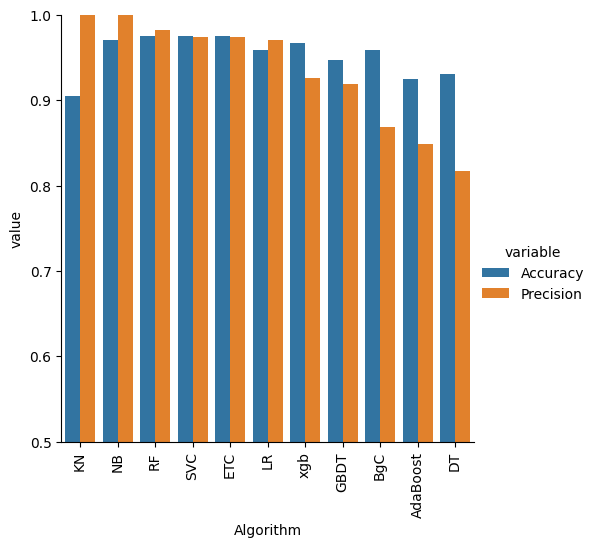

In [303]:
sns.catplot(x = 'Algorithm', y='value',
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

## Improvements

In [304]:
# model improve
# 1. Change the max_features parameter of TfIdf

In [305]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [306]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)

In [307]:
new_df = performance_df.merge(temp_df,on='Algorithm')

In [308]:
new_df_scaled = new_df.merge(temp_df,on='Algorithm')

In [309]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars',ascending=False)

In [310]:
new_df_scaled.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_scaling_x,Precision_scaling_x,Accuracy_scaling_y,Precision_scaling_y,Accuracy_num_chars,Precision_num_chars
0,KN,0.905222,1.000000,0.905222,1.000000,0.905222,1.000000,0.905222,1.000000
1,NB,0.970986,1.000000,0.970986,1.000000,0.970986,1.000000,0.970986,1.000000
2,RF,0.975822,0.982906,0.975822,0.982906,0.975822,0.982906,0.975822,0.982906
3,SVC,0.975822,0.974790,0.975822,0.974790,0.975822,0.974790,0.975822,0.974790
4,ETC,0.974855,0.974576,0.974855,0.974576,0.974855,0.974576,0.974855,0.974576
5,LR,0.958414,0.970297,0.958414,0.970297,0.958414,0.970297,0.958414,0.970297
6,xgb,0.967118,0.926230,0.967118,0.926230,0.967118,0.926230,0.967118,0.926230
7,GBDT,0.946809,0.919192,0.946809,0.919192,0.946809,0.919192,0.946809,0.919192
8,BgC,0.958414,0.868217,0.958414,0.868217,0.958414,0.868217,0.958414,0.868217
9,AdaBoost,0.924565,0.848837,0.924565,0.848837,0.924565,0.848837,0.924565,0.848837


In [311]:
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [312]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')

In [314]:
voting.fit(x_train,y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [316]:
y_pred = voting.predict(x_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9816247582205029
Precision 0.9917355371900827


In [317]:
# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [318]:
from sklearn.ensemble import StackingClassifier

In [319]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [320]:
clf.fit(x_train,y_train)
y_pred = clf.predict(x_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9806576402321083
Precision 0.9538461538461539


In [322]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))

## Website